# TXSA Assignment Part A

# Question 1 

## 1.1 Demonstrate word tokenisation using the split function, Regular Expression and NLTK packages separately and report the output. (2 marks)

In [ ]:
# import library
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

# Load data
with open('../Part_A/data/Data_1.txt', 'r', encoding='utf-8') as file:
    text_data = file.read()

# Tokenization Methods
tokens_split = text_data.split() #split
tokens_re = re.findall(r'\w+', text_data) #regex
tokens_nltk = word_tokenize(text_data) #nltk

# range to display (indices 15 to 25)
start, end = 15, 25

print(f"{'Index':<8} | {'Split()':<15} | {'Regex':<15} | {'NLTK':<15}")
print("-" * 60)

for i in range(start, end):
    # Handling potential index out of bounds
    s = tokens_split[i] if i < len(tokens_split) else ""
    r = tokens_re[i] if i < len(tokens_re) else ""
    n = tokens_nltk[i] if i < len(tokens_nltk) else ""
    
    print(f"{i:<8} | {s:<15} | {r:<15} | {n:<15}")

## 1.3 Demonstrate stop words and punctuations removal and report the output suitably along with the stop words found in the given text corpus. (2 marks)

In [ ]:
# 2. Filtering
stop_words = set(stopwords.words('english'))
punctuations = set(string.punctuation)

# unique stop words in the corpus
found_stop_words = sorted(list(set([w.lower() for w in tokens_nltk if w.lower() in stop_words])))

# Filtered tokens 
filtered_tokens = [w for w in tokens_nltk if w.lower() not in stop_words and w not in punctuations]

# --- Table Output ---
# 1. Headers
header1 = "Unique Stop Words Found"
header2 = "Filtered Tokens"

print(f"{'Index':<4} | {header1:<24} | {header2}")
print("-" * 50)

# 2. Determine the maximum length to iterate through both lists
max_len = max(len(found_stop_words), len(filtered_tokens[:50]))
# 3. Print side-by-side vertically
for i in range(max_len):
    # Get stop word if it exists at this index
    stop_word = found_stop_words[i] if i < len(found_stop_words) else ""
    # Get filtered token if it exists at this index 
    filtered_token = filtered_tokens[i] if i < 20 else ""
    # Only print if there is content in at least one column
    if stop_word or filtered_token:
        print(f"{i+1:<5} | {stop_word:<22}   |  {filtered_token}")

## 1.4 Explain the importance of filtering the stop words and punctuations in text analytics. (3 marks)

# Question 2

## 2.2 Demonstrate word stemming using Regular Expression, Porter Stemmer and Lancaster Stemmer and report the output (3 marks)

In [1]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer

# 1. Load Data_1.txt
with open("..\Part_A\data\Data_1.txt", "r", encoding="utf-8") as f:
    data_1 = f.read()


print("Data_1.txt:")
print(data_1)

Data_1.txt:
Classification is the task of choosing the correct class label for a given input. In basic
classification tasks, each input is considered in isolation from all other inputs, and the set of labels is defined in advance. The basic classification task has a number of interesting variants. For example, in multiclass classification, each instance may be assigned multiple labels; in open-class classification, the set of labels is not defined in advance; and in sequence classification, a list of inputs are jointly classified.


In [ ]:
# 2. Initialize stemmers
porter = PorterStemmer()
lancaster = LancasterStemmer()

# Implementing rule set for Regular Expression Stemmer
regex = RegexpStemmer('ing$|s$|ed$|able$|ion$|ment$', min=4)

# 3. Tokenize the Data_1.txt sentences into each word to undergo stemming
words = [w for w in word_tokenize(data_1)]

print("Data_1.txt - Word Tokenization:")
print(words)

Data_1.txt - Word Tokenization:
['Classification', 'is', 'the', 'task', 'of', 'choosing', 'the', 'correct', 'class', 'label', 'for', 'a', 'given', 'input', '.', 'In', 'basic', 'classification', 'tasks', ',', 'each', 'input', 'is', 'considered', 'in', 'isolation', 'from', 'all', 'other', 'inputs', ',', 'and', 'the', 'set', 'of', 'labels', 'is', 'defined', 'in', 'advance', '.', 'The', 'basic', 'classification', 'task', 'has', 'a', 'number', 'of', 'interesting', 'variants', '.', 'For', 'example', ',', 'in', 'multiclass', 'classification', ',', 'each', 'instance', 'may', 'be', 'assigned', 'multiple', 'labels', ';', 'in', 'open-class', 'classification', ',', 'the', 'set', 'of', 'labels', 'is', 'not', 'defined', 'in', 'advance', ';', 'and', 'in', 'sequence', 'classification', ',', 'a', 'list', 'of', 'inputs', 'are', 'jointly', 'classified', '.']


In [3]:
# 4. Sort words & Remove redundant words from output
words = sorted(list(set(words)))

print("Data_1.txt - SORTED Word Tokenization:")
print(words)

Data_1.txt - SORTED Word Tokenization:
[',', '.', ';', 'Classification', 'For', 'In', 'The', 'a', 'advance', 'all', 'and', 'are', 'assigned', 'basic', 'be', 'choosing', 'class', 'classification', 'classified', 'considered', 'correct', 'defined', 'each', 'example', 'for', 'from', 'given', 'has', 'in', 'input', 'inputs', 'instance', 'interesting', 'is', 'isolation', 'jointly', 'label', 'labels', 'list', 'may', 'multiclass', 'multiple', 'not', 'number', 'of', 'open-class', 'other', 'sequence', 'set', 'task', 'tasks', 'the', 'variants']


In [4]:
# 5. Comparison table
print(" \n 2.2 Demonstrate word stemming using Regular Expression, Porter Stemmer and Lancaster Stemmer and report the output. \n")
print(f"{'Original':<20} | {'Regular Expression':<20} | {'Porter':<20} | {'Lancaster':<20}")
print("-" * 90)
for each_word in words:
  # Regular Expression Stemming
    r_stem = regex.stem(each_word)
  # Porter Stemming
    p_stem = porter.stem(each_word)
  # Lancaster Stemming
    l_stem = lancaster.stem(each_word)
  # Print table
    print(f"{each_word:<20} | {r_stem:<20} | {p_stem:<20} | {l_stem:<20}")

 
 2.2 Demonstrate word stemming using Regular Expression, Porter Stemmer and Lancaster Stemmer and report the output. 

Original             | Regular Expression   | Porter               | Lancaster           
------------------------------------------------------------------------------------------
,                    | ,                    | ,                    | ,                   
.                    | .                    | .                    | .                   
;                    | ;                    | ;                    | ;                   
Classification       | Classificat          | classif              | class               
For                  | For                  | for                  | for                 
In                   | In                   | in                   | in                  
The                  | The                  | the                  | the                 
a                    | a                    | a                    |

---

# Question 3


## 3.1 DEMONSTRATE POS TAGGING (3 marks)

In [1]:
# Import Libraries and Setup
import nltk
from textblob import TextBlob
from nltk.chunk import RegexpParser
import svgling 

# Download required NLTK data
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to C:\Users\Sarvein
[nltk_data]     Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Sarvein Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Sarvein Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [16]:
# Load Input Sentence
with open("../Part_A/data/Data_2.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()

print("Input Sentence:")
print(sentence)

Input Sentence:
The big black dog barked at the white cat and chased away.


## 3.1.1 NLTK POS Tagger

In [17]:
print("\n1.1 NLTK POS TAGGER\n")

# Tokenize the sentence into individual words/tokens
tokens = nltk.word_tokenize(sentence)
print(f"\nTokenized Words ({len(tokens)} tokens):")
print(tokens)

# POS tagging 
nltk_pos = nltk.pos_tag(tokens)

print("\n\nNLTK POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")


# Penn Treebank POS tag set
pos_meanings = {
    'DT': 'Determiner',
    'JJ': 'Adjective',
    'NN': 'Noun, singular',
    'NNS': 'Noun, plural',
    'VBD': 'Verb, past tense',
    'VB': 'Verb, base form',
    'VBG': 'Verb, gerund/present participle',
    'VBP': 'Verb, non-3rd person singular present',
    'IN': 'Preposition/subordinating conjunction',
    'CC': 'Coordinating conjunction',
    'RB': 'Adverb',
    '.': 'Punctuation',
    ',': 'Comma',
    'PRP': 'Personal pronoun'
}

# Iterate through each word-tag pair and display with description
for word, tag in nltk_pos:
    # Get the meaning of the tag, default to the tag itself if not in dictionary
    meaning = pos_meanings.get(tag, tag)
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output (List of Tuples):")
print(nltk_pos)



1.1 NLTK POS TAGGER


Tokenized Words (13 tokens):
['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']


NLTK POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            RB         Adverb
.               .          Punctuation


Complete Output (List of Tuples):
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB'), ('.'

## 3.1.2 TextBlob POS Tagger

In [18]:
# Section 3.1.2: Part-of-Speech Tagging using TextBlob
print("\n\n3.1.2 TEXTBLOB POS TAGGER\n")

# Create a TextBlob object from the sentence
# TextBlob automatically tokenizes and tags the text
blob = TextBlob(sentence)

# Access the POS tags using the .tags property
textblob_pos = blob.tags

# Display formatted POS tagging results
print("TextBlob POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")

# Iterate through each word-tag pair and display with description
for word, tag in textblob_pos:
    # Get the meaning of the tag from the previously defined dictionary
    meaning = pos_meanings.get(tag, 'Unknown')
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output:")
print(list(textblob_pos))



3.1.2 TEXTBLOB POS TAGGER

TextBlob POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            RB         Adverb


Complete Output:
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB')]


## 3.1.3 Regular Expression Tagger

In [ ]:
# Section 3.1.3: Part-of-Speech Tagging using Regular Expressions
print("\n3.1.3 REGULAR EXPRESSION TAGGER\n")

# Define pattern-tag pairs for rule-based POS tagging
patterns = [
    (r'.*ing$', 'VBG'),               # gerunds
    (r'.*ed$', 'VBD'),                # simple past 
    (r'.*es$', 'VBZ'),                # 3rd singular present
    (r'.*ould$', 'MD'),               # modals
    (r".*\'s$", 'NN$'),               # possessive nouns
    (r'.*s$', 'NNS'),                 # plural nouns
    (r'^-?[0-9]+(.[0-9]+)?$', 'CD'),  # cardinal number
    (r'^(The|the|a|an)$', 'DT'),      # determiners
    (r'^(and|or|but)$', 'CC'),        # coordinating conjunctions
    (r'^(at|in|on|to|from)$', 'IN'),  # prepositions
    (r'.*ly$', 'RB'),                 # adverbs
    (r'.*', 'NN')                   
]

# Create a Regular Expression Tagger with the defined patterns
regexp_tagger = nltk.RegexpTagger(patterns)

# Apply the regex tagger to the previously tokenized words
regex_pos = regexp_tagger.tag(tokens)

# Display formatted POS tagging results
print("Regular Expression POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")

# Iterate through each word-tag pair and display with description
for word, tag in regex_pos:
    # Get the meaning of the tag from the dictionary
    meaning = pos_meanings.get(tag, 'Unknown')
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output:")
print(regex_pos)


3.1.3 REGULAR EXPRESSION TAGGER

Regular Expression POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             NN         Noun, singular
black           NN         Noun, singular
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           NN         Noun, singular
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            NN         Noun, singular
.               NN         Noun, singular


Complete Output:
[('The', 'DT'), ('big', 'NN'), ('black', 'NN'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'NN'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'NN'), ('.', 'NN')]


## 3.3 Draw Parse Trees



METHOD 1: CHUNK PARSER

Parse Tree Output:
(S
  (NP The/DT big/JJ black/JJ dog/NN)
  (VP barked/VBD)
  (PP at/IN (NP the/DT white/JJ cat/NN))
  and/CC
  (VP chased/VBD away/RB)
  ./.)


SVG Visualization (svgling):


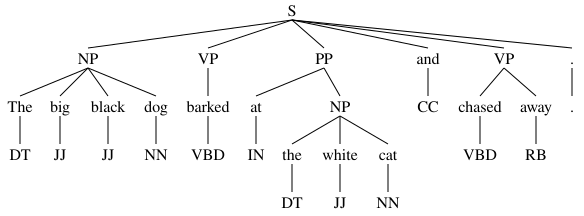

In [67]:
# QUESTION 3: PARSE TREES

# METHOD 1: Chunking using Chunk Parser
print("\n\nMETHOD 1: CHUNK PARSER\n")

# Define grammar rules for chunking using regular expressions
chunk_grammar = r"""
    NP: {<DT>?<JJ>*<NN.*>+}       
    VP: {<VB.*><RB>?}              
    VP: {<VB.*><IN><NP>}           
    PP: {<IN><NP>}                 
"""

# Create a chunk parser with the defined grammar rules
chunk_parser = RegexpParser(chunk_grammar)

# Parse the POS-tagged tokens to identify and group phrases
# Returns a tree structure with labeled chunks
chunked_tree = chunk_parser.parse(nltk_pos)

# Display the tree structure in text format
print("Parse Tree Output:")
print(chunked_tree)


# Display with svgling for beautiful SVG visualization
print("\n\nSVG Visualization (svgling):")
display(chunked_tree)



METHOD 2: CONTEXT-FREE GRAMMAR PARSER



Parse Tree Output:
(S
  (NP (DT The) (ADJP (JJ big) (JJ black)) (NN dog))
  (VP
    (VBD barked)
    (PP (IN at) (NP (DT the) (ADJP (JJ white)) (NN cat))))
  (CC and)
  (VP (VBD chased) (RB away)))

SVG Visualization (svgling):


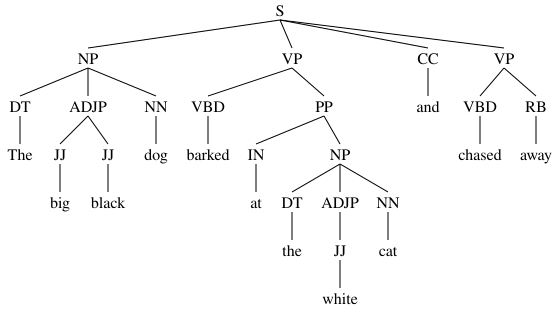

In [68]:
# METHOD 2: Parsing using Context-Free Grammar (CFG)
print("\n\nMETHOD 2: CONTEXT-FREE GRAMMAR PARSER\n")

with open("../Part_A/data/Data_2.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()

tokens = nltk.word_tokenize(sentence)
nltk_pos = nltk.pos_tag(tokens)

# Define a context-free grammar with production rules
cfg_grammar = nltk.CFG.fromstring("""
    S -> NP VP                     
    S -> NP VP CC VP               
    
    NP -> DT ADJP NN               
    NP -> DT NN                    
    
    ADJP -> JJ JJ                  
    ADJP -> JJ                     
    
    VP -> VBD PP                   
    VP -> VBD RB                   
    
    PP -> IN NP                    
    
    DT -> 'The' | 'the'            
    JJ -> 'big' | 'black' | 'white'
    NN -> 'dog' | 'cat'
    VBD -> 'barked' | 'chased'
    IN -> 'at'
    CC -> 'and'
    RB -> 'away'
""")

# Remove punctuation from tokens for cleaner parsing
parse_tokens = [word for word in tokens if word != '.']

# Create a chart parser with the defined CFG grammar
parser = nltk.ChartParser(cfg_grammar)

# Parse the tokens and generate all possible parse trees
parse_trees = list(parser.parse(parse_tokens))


# Display each parse tree with both text and visual formats
for i, tree in enumerate(parse_trees, 1):
    print(f"\n\nParse Tree Output:")
    print(tree)
    print("\nSVG Visualization (svgling):")
    display(tree)

# Question 4

In [4]:
#1 Open the file and read everything inside it as one big string

with open("../Part_A/data/Data_3.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text)


Training Corpus
~~~~~~~~~~~~~
<s> He read a book </s>
<s> I read a different book </s>
<s> He read a book by Danielle </s>

Calculate sentence probability for the following sentence
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
<s> I read a different book by Danielle </s>


2) Step 2 — Preprocess (keep <s> and </s>)
What preprocessing we do (simple + safe)

We:

split by lines (each line is one sentence)

split each sentence by spaces (so <s> and </s> stay as tokens)

remove any empty pieces

In [5]:
# 2) Split into lines, keep only training sentences (lines starting with <s>)
lines = [line.strip() for line in text.splitlines() if line.strip().startswith('<s>')]

# 3) Split each line into tokens by spaces (keeps <s> and </s>)
# Use only first 3 lines as training corpus (excludes the test sentence at the bottom)
sentences = [line.split() for line in lines[:3]]

print(sentences)


[['<s>', 'He', 'read', 'a', 'book', '</s>'], ['<s>', 'I', 'read', 'a', 'different', 'book', '</s>'], ['<s>', 'He', 'read', 'a', 'book', 'by', 'Danielle', '</s>']]


In [6]:
from collections import Counter

# Flatten all tokens into one list
all_tokens = [tok for sent in sentences for tok in sent]

# Count unigrams (single tokens)
unigram_counts = Counter(all_tokens)

# Count bigrams (pairs)
bigram_counts = Counter()
for sent in sentences:
    for i in range(len(sent) - 1):
        bigram_counts[(sent[i], sent[i+1])] += 1

print("count(<s>) =", unigram_counts["<s>"])
print("count(<s>, I) =", bigram_counts[("<s>", "I")])


count(<s>) = 3
count(<s>, I) = 1


In [7]:
def sentence_probability(tokens, unigram_counts, bigram_counts, V, smoothing=False):
    prob = 1.0

    for i in range(1, len(tokens)):
        prev_word = tokens[i-1]
        word = tokens[i]

        bigram = (prev_word, word)

        if smoothing:
            numerator = bigram_counts[bigram] + 1
            denominator = unigram_counts[prev_word] + V
        else:
            numerator = bigram_counts[bigram]
            denominator = unigram_counts[prev_word]

            # If a bigram was never seen, probability becomes 0
            if numerator == 0:
                return 0.0

        prob *= numerator / denominator

    return prob


In [8]:
test_sentence = "<s> I read a different book by Danielle </s>".split()

V = len(set(all_tokens))  # vocabulary size

unsmoothed = sentence_probability(test_sentence, unigram_counts, bigram_counts, V, smoothing=False)
smoothed = sentence_probability(test_sentence, unigram_counts, bigram_counts, V, smoothing=True)

print("Vocabulary size V =", V)
print("Unsmoothed probability =", unsmoothed)
print("Smoothed probability   =", smoothed)


Vocabulary size V = 10
Unsmoothed probability = 0.037037037037037035
Smoothed probability   = 1.2244070205767176e-06


# Question 5 ( Indivdual )

## Rama

###  Q5. Alternative Approach Implementation - spaCy Tokenization

Alternative tokenization using spaCy 

In [10]:
# Import spaCy library
%pip install spacy
import spacy


# Read & Display Data_1.txt
with open("../Part_A/data/Data_1.txt", "r", encoding="utf-8") as f:
        paragraph = f.read().strip()


print("Data_1.txt:")
print(paragraph, "\n")



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp313-cp313-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp313-cp313-win_amd64.whl.metadata (9.9 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached blis-1.3.3-cp313-cp313-win_amd64.whl.metadata (7.7 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached cloudpathlib-0.23.0-py3-none-any.whl.metadata (16 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   -----------------------------

In [12]:
# PART 1: Word Tokenization using spaCy (2 marks)
print("PART 1: Word Tokenization using spaCy")

!python -m spacy download en_core_web_sm

# English-language model for spaCy
nlp = spacy.load("en_core_web_sm")

# Tokenize the paragraph
doc = nlp(paragraph)

# Display spaCy tokens
spacy_tokens = [token.text for token in doc]
print(f"\nTotal tokens (spaCy): {len(spacy_tokens)}")
print("\n Acquired spaCy tokens :")
print(spacy_tokens)
print("\n")



PART 1: Word Tokenization using spaCy
Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Total tokens (spaCy): 97

 Acquired spaCy tokens :
['Classification', 'is', 'the', 'task', 'of', 'choosing', 'the', 'correct', 'class', 'label', 'for', 'a', 'given', 'input', '.', 'In', 'basic', '\n', 'classification', 'tasks', ',', 'each', 'input', 'is', 'considered', 'in', 'isolation', 'from', 'all', 'other', 'inputs', ',', 'and', 'the', 'set', 'of', 'labels', 'is', 'defined', 'in', 'advance', '.', 'The', 'basic', 'classification', 'task', 'has', 'a', 'number', 'of', 'interesting', 'variants', '.', 'For', 'example', ',', 'in', 'multiclass', 'classification', ',', 'each', 'instance', 'may', 'be', 'assigned', 'multiple', 'labels', ';', 'in', 'open', '-', 'class', 'classification', ',', 'the', 'set', 'of', 'labels', 'is', 'not', 'defined', 'in', 'advance', ';', 'and', 'in', 'sequence', 'classification', ',', 'a', 'list', 'of', 'inputs', 'are', 'jointly', 'classified', '.']




## Sarvein

###  Q5. Alternative Approach Implementation - TextBlob Tokenization
Alternative tokenization using TextBlob 

In [13]:
# Import Libraries

from textblob import TextBlob
import string


In [14]:
# Load Input Sentence
with open("../Part_A/data/Data_1.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()


print("INPUT SENTENCE:")
print(sentence)


INPUT SENTENCE:
Classification is the task of choosing the correct class label for a given input. In basic
classification tasks, each input is considered in isolation from all other inputs, and the set of labels is defined in advance. The basic classification task has a number of interesting variants. For example, in multiclass classification, each instance may be assigned multiple labels; in open-class classification, the set of labels is not defined in advance; and in sequence classification, a list of inputs are jointly classified.


In [15]:
# PART 1: Word Tokenization using TextBlob (2 marks)
print("PART 1: WORD TOKENIZATION USING TEXTBLOB")

# Create TextBlob object
blob = TextBlob(sentence)

# Tokenize words
tokens = blob.words

print(f"\nTotal number of tokens: {len(tokens)}\n")
print("Tokenized words:")
print(tokens)
print("\n")

PART 1: WORD TOKENIZATION USING TEXTBLOB

Total number of tokens: 82

Tokenized words:
['Classification', 'is', 'the', 'task', 'of', 'choosing', 'the', 'correct', 'class', 'label', 'for', 'a', 'given', 'input', 'In', 'basic', 'classification', 'tasks', 'each', 'input', 'is', 'considered', 'in', 'isolation', 'from', 'all', 'other', 'inputs', 'and', 'the', 'set', 'of', 'labels', 'is', 'defined', 'in', 'advance', 'The', 'basic', 'classification', 'task', 'has', 'a', 'number', 'of', 'interesting', 'variants', 'For', 'example', 'in', 'multiclass', 'classification', 'each', 'instance', 'may', 'be', 'assigned', 'multiple', 'labels', 'in', 'open-class', 'classification', 'the', 'set', 'of', 'labels', 'is', 'not', 'defined', 'in', 'advance', 'and', 'in', 'sequence', 'classification', 'a', 'list', 'of', 'inputs', 'are', 'jointly', 'classified']




## Irfan

In [16]:
# Question 5: Alternative Approach (Scikit-learn) 
from sklearn.feature_extraction.text import CountVectorizer

with open('../Part_A/data/Data_1.txt', 'r', encoding='utf-8') as file:
    text_data = file.read()

# 1. Initialize and Fit
vect = CountVectorizer()
corpus = [text_data] 
X = vect.fit_transform(corpus) 

# 2. Extract items from the vocabulary
# .items() gives us both the 'word' and the 'alphabetical_index'
# It follows the discovery order (how they first appear in the text)
vocab_items = list(vect.vocabulary_.items())

# 3. Table Output Display
print(f"{'No.':<5} | {'Token':<20} | {'Assigned ID (Alphabetical)'}")
print("-" * 55)

# Show the first 20 tokens found in the text
for i, (token, alpha_idx) in enumerate(vocab_items[:20]):
    # i+1 is no of token
    # token is word
    # alpha_idx is assigned number to token alphabetically
    print(f" {i+1:<4} | {token:<20} | {alpha_idx}")

No.   | Token                | Assigned ID (Alphabetical)
-------------------------------------------------------
 1    | classification       | 9
 2    | is                   | 25
 3    | the                  | 43
 4    | task                 | 41
 5    | of                   | 36
 6    | choosing             | 7
 7    | correct              | 12
 8    | class                | 8
 9    | label                | 28
 10   | for                  | 16
 11   | given                | 18
 12   | input                | 21
 13   | in                   | 20
 14   | basic                | 5
 15   | tasks                | 42
 16   | each                 | 14
 17   | considered           | 11
 18   | isolation            | 26
 19   | from                 | 17
 20   | all                  | 1


## Kai Wen: Hugging Face Tokenization (Alternative Approach)

This section uses a Hugging Face tokenizer as an alternative to the Part 1 approaches (split, regex, and NLTK) to show tokenization, stop word removal, and punctuation filtering. It also summarizes how this method compares to the earlier approaches.


In [17]:
%pip install transformers

Defaulting to user installation because normal site-packages is not writeable
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/10.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.1 MB 2.0 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/10.1 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/10.1 MB 1.7 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/10.1 MB 1.7 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/10.1 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/10.1 MB 1.3 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/10.1 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/10.1 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/10.1 MB 1.1 MB/s eta 0:00:08
   -------- --


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from transformers import AutoTokenizer

# 1. Load the tokenizer
# No need for NLTK or manual string/stopword lists
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

with open('../Part_A/data/Data_1.txt', 'r', encoding='utf-8') as file:
    text_data = file.read()

# 2. Pure Hugging Face Encoding
# 'encode' converts text to Token IDs. 'tokenize' converts text to subword strings.
# Using 'encode_plus' or the __call__ method is the standard for model prep.
encoding = tokenizer(
    text_data,
    add_special_tokens=True,    # Adds [CLS] and [SEP]
    truncation=True,           # Cuts text if it's longer than model max (usually 512)
    padding='max_length',      # Pads to max length (optional, usually for batching)
    return_attention_mask=True # Tells the model which tokens are real vs padding
)

# 3. Accessing the results
hf_tokens = tokenizer.tokenize(text_data) # The subword strings
hf_ids = encoding['input_ids']            # The numerical IDs for the model

print('Hugging Face Tokenization:')
print(f'Total subword tokens: {len(hf_tokens)}')
print('Sample Tokens:', hf_tokens[:20])
print('Sample IDs:', hf_ids[:20])

# To see how it handles "cleaning" naturally:
print('\nDecoded example (how the model sees it):')
print(tokenizer.decode(hf_ids[:20]))

C:\Users\Sarvein Rao\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Sarvein Rao\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sarvein Rao\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrat

Hugging Face Tokenization:
Total subword tokens: 97
Sample Tokens: ['classification', 'is', 'the', 'task', 'of', 'choosing', 'the', 'correct', 'class', 'label', 'for', 'a', 'given', 'input', '.', 'in', 'basic', 'classification', 'tasks', ',']
Sample IDs: [101, 5579, 2003, 1996, 4708, 1997, 10549, 1996, 6149, 2465, 3830, 2005, 1037, 2445, 7953, 1012, 1999, 3937, 5579, 8518]

Decoded example (how the model sees it):
[CLS] classification is the task of choosing the correct class label for a given input. in basic classification tasks


### Comparison: Traditional NLP vs Hugging Face Tokenization

#### **1. Core Differences**

| Aspect | Traditional (NLTK/Regex) | Hugging Face (Transformers) |
|--------|-------------------------|----------------------------|
| **Tokenization** | Word-level (splits on spaces/punctuation) | Subword-level (WordPiece, BPE) |
| **Preprocessing** | Manual (lowercase, remove stopwords, punctuation) | Automatic (model-specific) |
| **Output** | List of string tokens | Token IDs + attention masks |
| **Vocabulary** | Unlimited (any word in text) | Fixed (32k-50k subwords) |
| **Purpose** | General text processing | Model-ready input for transformers |

---

#### **2. Key Technical Contrasts**

**Traditional Approach:**
```python
tokens_nltk = word_tokenize(text_data)  # → ["running", "quickly"]
filtered = [w for w in tokens if w.lower() not in stopwords]  # Manual filtering
```

**Hugging Face Approach:**
```python
encoding = tokenizer(text_data)  # → [101, 2770, 3089, 102]
# "running" → ["run", "##ning"]  # Subword splitting
```

---

#### **3. When Each Is Better**

**Traditional (NLTK) is Better When:**
- ✅ You need **human-readable tokens** for analysis
- ✅ Building **bag-of-words models** or **TF-IDF**
- ✅ Performing **linguistic analysis** (POS tagging, dependency parsing)
- ✅ Working with **small datasets** or **rule-based systems**
- ✅ You want **full control** over preprocessing steps

**Hugging Face is Better When:**
- ✅ Using **transformer models** (BERT, GPT, RoBERTa)
- ✅ Need to handle **rare/unknown words** (subwords prevent OOV issues)
- ✅ Want **consistent preprocessing** with pre-trained models
- ✅ Building **production ML pipelines** (fewer preprocessing steps)
- ✅ Working with **multilingual text** (handles 100+ languages)

---

#### **4. Critical Trade-offs**

| Factor | Traditional | Hugging Face |
|--------|-------------|--------------|
| **Interpretability** | High (readable words) | Low (subword fragments) |
| **OOV Handling** | Poor (unknown words dropped) | Excellent (splits into known subwords) |
| **Setup Complexity** | Low (manual steps) | Medium (requires model download) |
| **Memory Usage** | Low | High (tokenizer + vocab files) |
| **Speed** | Fast (simple string ops) | Slower (model-specific encoding) |

---

#### **5. Example: How They Handle "Unbelievable"**
```python
# Traditional NLTK
tokens_nltk = ["Unbelievable", "!"]  # Keeps full word, separate punctuation

# Hugging Face (BERT)
hf_tokens = ["un", "##believable"]   # Splits into known subword pieces
hf_ids = [4895, 22936]               # Converts to model input IDs
```

---

#### **6. Final Verdict**

**Not better or worse — fundamentally different tools:**
- **Use Traditional** for exploratory analysis, visualization, classical ML (Naive Bayes, SVM)
- **Use Hugging Face** for deep learning, pre-trained models, production NLP systems

**Modern best practice:** Use HF tokenizers for model input, but keep traditional methods for data exploration and validation.